## TEST Finetune on random images

In [2]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
import os
import requests

import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

# check whether run in Colab
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip3 install timm==0.4.5  # 0.3.2 does not work in Colab
    !git clone https://github.com/facebookresearch/mae.git
    sys.path.append('./mae')
else:
    sys.path.append('..')
import models_vit

from pytorch_grad_cam import GradCAM,HiResCAM,ScoreCAM,GradCAMPlusPlus,AblationCAM,XGradCAM,EigenCAM,FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
import json
from pathlib import Path
from collections import OrderedDict

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])


/opt/anaconda3/envs/jbescop_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/anaconda3/envs/jbescop_env/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


/opt/anaconda3/envs/jbescop_env/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## UTILITY FUNCTIONS

In [3]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def prepare_model(chkpt_dir, arch='mae_vit_large_patch16'):
    # build model
    model = models_vit.__dict__[arch](
        num_classes=2,
        global_pool=False,
    )
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def prepare_model_special(chkpt_dir, arch='vit_large_patch16'):
    # build model
    model = models_vit.__dict__[arch](
        num_classes=2,
        global_pool=False,
    )
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu',weights_only=True)
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def run_one_image(img, model):
    x = torch.tensor(img)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)

    # run MAE
    y = model(x.float())
    return y 

def read_json(fname):
    fname = Path(fname)
    with fname.open('rt') as handle:
        return json.load(handle, object_hook=OrderedDict)

In [5]:
#################################################
chkpt_dir = './finetune3/best_model.pth'
model_mae_classif = prepare_model(chkpt_dir, 'vit_large_patch16')

<All keys matched successfully>


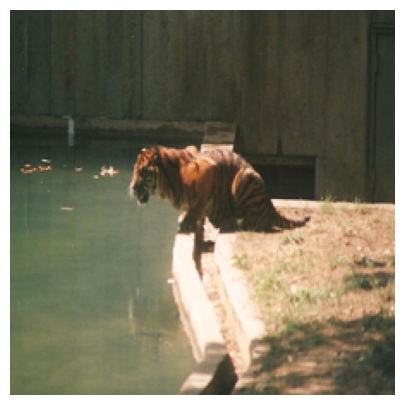

In [7]:
img_path = "../../data/cat_dog/test/cat/75.jpg"
img_true= Image.open(img_path)
img_resized = img_true.resize((224, 224))
img_float = np.array(img_resized) / 255.

assert img_float.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img_float - imagenet_mean
img_tsf = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img_tsf))

In [8]:
result = run_one_image(img_tsf, model_mae_classif)
# Optionally compute probabilities
probabilities = torch.softmax(result, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['cat', 'dog']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)


Probabilities: tensor([[0.9533, 0.0467]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([0])
Predicted classes: ['cat']


## GRAD CAM CHECKING

In [4]:
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1 :  , :].reshape(tensor.size(0),
        height, width, tensor.size(2))

    # Bring the channels to the first dimension,
    # like in CNNs.
    result = result.transpose(2, 3).transpose(1, 2)
    return result

trsfm = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(), # convert between 0 and 1
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])

        ])


torch.Size([3, 224, 224])


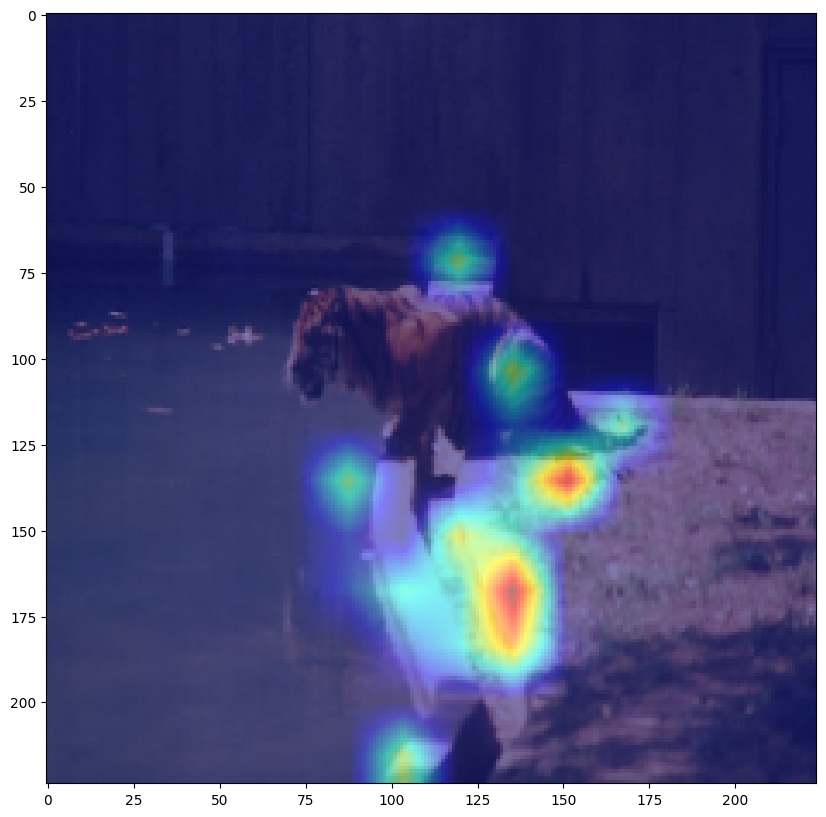

In [37]:
#img_torch = torch.from_numpy(img_float)
img_transformed = trsfm(img_true)
print(img_transformed.shape)
input_image = img_transformed.unsqueeze(0)

#input_tensor = input_image.to(device)
target_layers = [model_mae_classif.blocks[-1].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam = GradCAM(model=model_mae_classif,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

#empty image for test purpose
vide = np.zeros((224,224,3))
# Permute the dimensions to change the order
tensor_permuted = img_transformed.permute(1, 2, 0)
tensor_permuted_float = tensor_permuted.float()
# Scale values between 0 and 1
tensor_permuted_float = tensor_permuted_float / tensor_permuted_float.max()
# Convert the tensor to a NumPy array
numpy_array = tensor_permuted_float.numpy()

#transpose numpy_array to image original look
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_transposed = tensor_permuted* std + mean
img_transposed = np.clip(img_transposed,0,1)

grayscale_cam = cam(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]
visualization = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)



plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
plt.imshow(visualization)

## RAILSEM TEST FROM HERE

In [25]:
#################################################
#chkpt_dir_railsem = './finetune/finetune_railsem4_balanced_10000/best_model.pth'
chkpt_dir_railsem_nomask = './output_dir/finetune/finetune_railsem_nomask_nopretrain/best_model.pth'
chkpt_dir_railsem_mask = './output_dir/finetune_thesis/finetune_railsem_masked_distance_nopretrain/best_model.pth'
chkpt_PRETRAINED = './output_dir/finetune/finetune_railsem_nomask_pretrained/best_model.pth'
#chkpt_dir_vit_users_median = './finetune/finetune_VIT_Users_2vsall/best_model.pth'
#chkpt_dir_vit_classif = '../thesis1/saved/Tab2/fold2/models/median_UsersVitClassif_Users_2vsall/median_UsersVitClassif_Users_2vsall/model_best.pth'
model_mae_classif_railsem_mask = prepare_model(chkpt_dir_railsem_mask,'vit_base_patch16')
model_mae_classif_railsem_nomask = prepare_model(chkpt_dir_railsem_nomask, 'vit_base_patch16')
model_mae_classif_PRETRAINED = prepare_model(chkpt_PRETRAINED, 'vit_base_patch16')
#model_mae_classif_vit_users_median = prepare_model(chkpt_dir_vit_users_median,'vit_base_patch16')
#model_mae_classif_vit_classif = prepare_model_special(chkpt_dir_vit_classif,'vit_base_patch16')


<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>


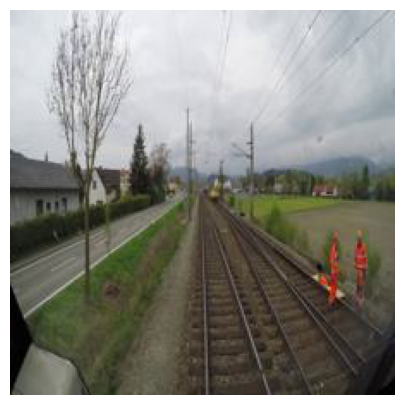

In [28]:
img_path = "../../data/railsem19/2vsall/train/risky/rs07217.jpg" ##RAILSEM19 TRAINING
#img_path = "../../data/railsem19/2vsall/train/risky/rs03983.jpg" ##RAILSEM19 TRAINING
#img_path = "../../data/railsem19/2vsall_bl_2/test/risky/rs07227.jpg"#railsem balanced
#img_path = "../../data/images/rs19_224/rs00202.jpg" ##RAILSEM19 ALL
#img_path="../../data/cat_dog/test/cat/94.jpg" ##CATDOG
#img_path = "../../data/simulator/synthetic/3_forest/images/8.png" ##SIMULATOR
img_true= Image.open(img_path)
img_resized = img_true.resize((224, 224))
img_float = np.array(img_resized) / 255.
img_jpg = img_float[:,:,:3]

assert img_jpg.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img_jpg - imagenet_mean
img_tsf = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img_tsf))

In [29]:
result_nomask = run_one_image(img_tsf, model_mae_classif_railsem_nomask)
result_mask = run_one_image(img_tsf,model_mae_classif_railsem_mask)
#result_mask = run_one_image(img_tsf,model_mae_classif_vit_users_median)
# Optionally compute probabilities

## Here test the nomask
probabilities = torch.softmax(result_nomask, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result_nomask, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['risky', 'safe']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)

##Here test the masked
probabilities = torch.softmax(result_mask, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result_mask, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['risky', 'safe']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)

Probabilities: tensor([[0.0967, 0.9033]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([1])
Predicted classes: ['safe']
Probabilities: tensor([[0.6655, 0.3345]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([0])
Predicted classes: ['risky']


### Grad cam checking

torch.Size([3, 224, 224])


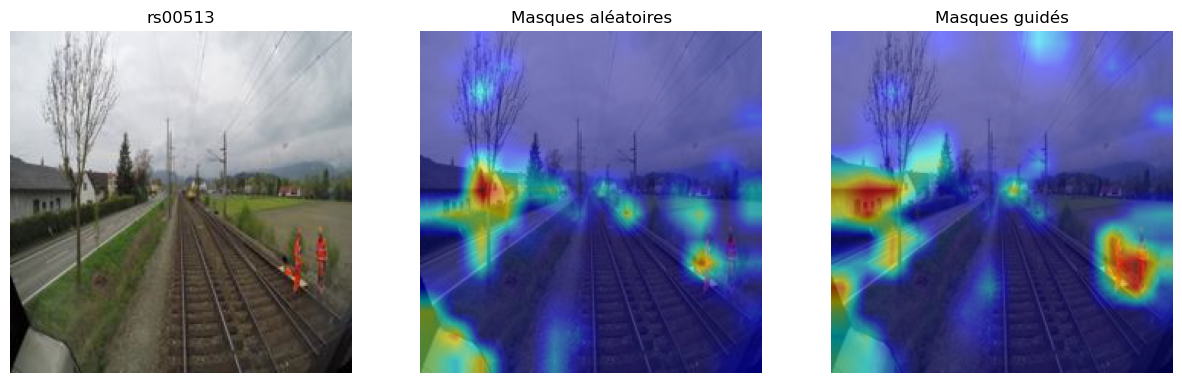

In [30]:
#img_torch = torch.from_numpy(img_float)
selecthead = -1
img_transformed = trsfm(img_true)
print(img_transformed.shape)
input_image = img_transformed.unsqueeze(0)

#input_tensor = input_image.to(device)
target_layers = [model_mae_classif_railsem_nomask.blocks[selecthead].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam1 = GradCAM(model=model_mae_classif_railsem_nomask,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

#empty image for test purpose
vide = np.zeros((224,224,3))
# Permute the dimensions to change the order
tensor_permuted = img_transformed.permute(1, 2, 0)
tensor_permuted_float = tensor_permuted.float()
# Scale values between 0 and 1
tensor_permuted_float = tensor_permuted_float / tensor_permuted_float.max()
# Convert the tensor to a NumPy array
numpy_array = tensor_permuted_float.numpy()

#transpose numpy_array to image original look
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_transposed = tensor_permuted* std + mean
img_transposed = np.clip(img_transposed,0,1)

grayscale_cam = cam1(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]

visualization1 = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)

target_layers = [model_mae_classif_railsem_mask.blocks[selecthead].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam2 = GradCAM(model=model_mae_classif_railsem_mask,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

grayscale_cam = cam2(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]
visualization2 = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 15))

axes[0].imshow(img_jpg)
axes[0].axis("off")  # Hide axes
axes[0].set_title("rs00513")

# Display the first image
axes[1].imshow(visualization1)
axes[1].axis("off")  # Hide axes
axes[1].set_title("Masques aléatoires")

# Display the second image
axes[2].imshow(visualization2)
axes[2].axis("off")  # Hide axes
axes[2].set_title("Masques guidés")

# Show the figure
plt.show()

## INVESTIGATION SANDBOX
### DIRTY CODE

In [17]:
# Add this at the top of your notebook or script
import sys
import types
sys.path.append('../thesis1/')
from parse_config import ConfigParser
import model.model as module_arch
chkpt_config_path_users_median = '../thesis1/config/EXPVISAPP2/Tab2/fold2/median/2vsall/vit_pre_Users.json'
chkpt_dir_vit_users_median = '../thesis1/saved/Tab2/fold2/models/median_UsersVitClassif_Context_2vsall/median_UsersVitClassif_Context_2vsall/model_best.pth'

config = read_json(config_path)  # make sure to copy this too
config_main = ConfigParser(config=config, resume=model_path)
model = config_main.init_obj('arch', module_arch)


ckpt = torch.load(chkpt_dir_vit_users_median, map_location='cpu')
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt['model']


ImportError: cannot import name 'ConfigParser' from 'parse_config' (unknown location)

## REGARDER LES IMAGES POUR LESQUELLES LE MODELE SE TROMPE !

Dossier: ../../data/railsem19/2vsall/train/risky/
GT_IS_RISKY = True -> erreurs considérées: FN (prédit SAFE mais GT RISKY)
Total images: 633 | Mauvaises prédictions: 18


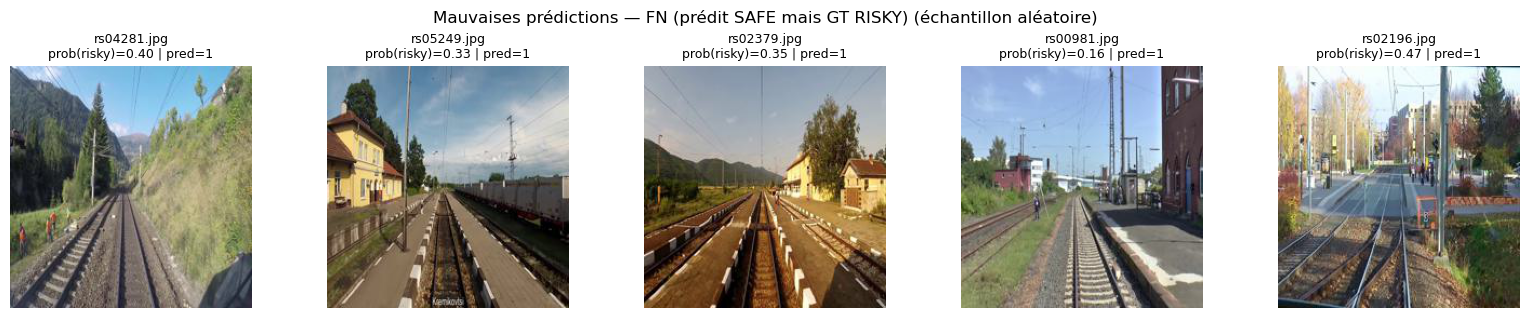


Échantillon d'erreurs affichées :
- rs04281.jpg | prob(risky)=0.40
- rs05249.jpg | prob(risky)=0.33
- rs02379.jpg | prob(risky)=0.35
- rs00981.jpg | prob(risky)=0.16
- rs02196.jpg | prob(risky)=0.47


In [9]:
# --- ⬇️ Paramètres à ajuster ⬇️ ---
IMG_DIR = "../../data/railsem19/2vsall/train/risky/"   # ex: "risky/" ou "safe/"
GT_IS_RISKY = True                                    # True si le dossier contient UNIQUEMENT des images "risky", False si "safe"
MODEL = globals().get('model_mae_classif_railsem_mask', None)  # ton modèle
BATCH_SIZE = 64
POS_IDX = 0             # indice de la classe "risky" si sortie softmax à 2 classes (ex: [safe, risky])
THRESH = 0.5            # seuil si ton modèle sort un logit unique (sigmoïde)
N_SHOW = 5              # nb max d'images mal prédites à afficher
SHUFFLE = True          # affichage aléatoire des erreurs
SEED = None             # mets un int (ex: 42) pour un affichage reproductible
# --- ⬆️ Paramètres à ajuster ⬆️ ---

import os, glob, random
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt

assert MODEL is not None, "Aucun modèle trouvé (ex: model_mae_classif_railsem_nomask)."

if SEED is not None:
    random.seed(SEED)

device = next(MODEL.parameters()).device
MODEL.eval()

# Transfos standard (ajuste si besoin)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Dé-normalisation pour affichage
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(1,3,1,1)
IMAGENET_STD_T  = torch.tensor(IMAGENET_STD).view(1,3,1,1)
def denorm(x):  # x: [N,3,H,W] (CPU)
    return (x * IMAGENET_STD_T + IMAGENET_MEAN_T).clamp(0,1)

# Récupère les chemins d'images
exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp","*.tif","*.tiff")
all_paths = []
for e in exts:
    all_paths += glob.glob(os.path.join(IMG_DIR, e))
all_paths = sorted(all_paths)
assert len(all_paths) > 0, f"Aucune image trouvée dans {IMG_DIR}"

# Inférence par batch
bad_paths, bad_probs, bad_pred_lbl = [], [], []  # erreurs (FN si GT risky, FP si GT safe)
with torch.no_grad():
    for i in range(0, len(all_paths), BATCH_SIZE):
        batch_paths = all_paths[i:i+BATCH_SIZE]
        imgs = []
        for p in batch_paths:
            try:
                im = Image.open(p).convert("RGB")
                imgs.append(tfm(im))
            except Exception as e:
                print(f"[WARN] Impossible de charger {p}: {e}")
        if not imgs:
            continue

        batch = torch.stack(imgs, dim=0).to(device)
        logits = MODEL(batch.float())

        # Cas binaire 1 logit vs multi-classes
        if logits.ndim == 2 and logits.shape[1] == 1:
            prob_risky = torch.sigmoid(logits.squeeze(1))
            pred_is_risky = (prob_risky >= THRESH)
            pred_lbl = pred_is_risky.long()  # 0=safe, 1=risky
        elif logits.ndim == 2:
            probs = F.softmax(logits, dim=1)
            prob_risky = probs[:, POS_IDX]
            pred_lbl = torch.argmax(probs, dim=1)
            pred_is_risky = (pred_lbl == POS_IDX)
        else:
            prob_risky = torch.sigmoid(logits)
            pred_is_risky = (prob_risky >= THRESH)
            pred_lbl = pred_is_risky.long()

        # Si GT = risky, erreur = prédiction "safe" -> FN
        # Si GT = safe,  erreur = prédiction "risky" -> FP
        err_mask = (~pred_is_risky) if GT_IS_RISKY else (pred_is_risky)

        err_idx = torch.where(err_mask)[0].tolist()
        for j in err_idx:
            bad_paths.append(batch_paths[j])
            bad_probs.append(float(prob_risky[j].detach().cpu()))
            bad_pred_lbl.append(int(pred_lbl[j].detach().cpu()))

# Résumé
total = len(all_paths)
nb_err = len(bad_paths)
nature = "FN (prédit SAFE mais GT RISKY)" if GT_IS_RISKY else "FP (prédit RISKY mais GT SAFE)"
print(f"Dossier: {IMG_DIR}")
print(f"GT_IS_RISKY = {GT_IS_RISKY} -> erreurs considérées: {nature}")
print(f"Total images: {total} | Mauvaises prédictions: {nb_err}")

# Affichage d'un SOUS-ENSEMBLE ALÉATOIRE d'erreurs
if nb_err == 0:
    print("✅ Aucune mauvaise prédiction trouvée.")
else:
    k = min(N_SHOW, nb_err)
    indices = list(range(nb_err))
    if SHUFFLE:
        random.shuffle(indices)
    sel_idx = indices[:k]

    to_show_paths  = [bad_paths[i]     for i in sel_idx]
    to_show_probs  = [bad_probs[i]     for i in sel_idx]
    to_show_plabel = [bad_pred_lbl[i]  for i in sel_idx]

    # Recharge et affiche
    imgs_show = []
    for p in to_show_paths:
        try:
            im = Image.open(p).convert("RGB")
            imgs_show.append(tfm(im))
        except:
            imgs_show.append(None)

    valid_pairs = [(p, pr, pl, im) for p, pr, pl, im in zip(to_show_paths, to_show_probs, to_show_plabel, imgs_show) if im is not None]
    if valid_pairs:
        batch_show = torch.stack([im for _,_,_,im in valid_pairs], dim=0).cpu()
        batch_show = denorm(batch_show)

        n = batch_show.size(0)
        cols = min(n, 5)
        rows = (n + cols - 1)//cols
        fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 3.2*rows))
        if rows == 1 and cols == 1:
            axes = [[axes]]
        elif rows == 1:
            axes = [axes]
        elif cols == 1:
            axes = [[ax] for ax in axes]

        for idx in range(rows*cols):
            r, c = divmod(idx, cols)
            ax = axes[r][c]
            if idx < n:
                img_np = batch_show[idx].permute(1,2,0).numpy()
                ax.imshow(img_np)
                base = os.path.basename(valid_pairs[idx][0])
                prob = valid_pairs[idx][1]
                plbl = valid_pairs[idx][2]
                ax.set_title(f"{base}\nprob(risky)={prob:.2f} | pred={plbl}", fontsize=9)
                ax.axis('off')
            else:
                ax.axis('off')
        fig.suptitle(f"Mauvaises prédictions — {nature} (échantillon aléatoire)", fontsize=12)
        plt.tight_layout()
        plt.show()

    # En complément: aperçu textuel (échantillon aléatoire identique à l'affichage)
    print("\nÉchantillon d'erreurs affichées :")
    for p, pr in zip(to_show_paths, to_show_probs):
        print(f"- {os.path.basename(p)} | prob(risky)={pr:.2f}")

# 📌 Utilisation :
# - Dossier RISKY : IMG_DIR=.../risky/ , GT_IS_RISKY=True  -> détecte les FN (prédit SAFE)
# - Dossier SAFE  : IMG_DIR=.../safe/  , GT_IS_RISKY=False -> détecte les FP (prédit RISKY)
# - 2 classes [safe, risky] -> règle POS_IDX (par défaut 1).
# - Sortie logit unique (risky) -> THRESH=0.5.
# - Affichage aléatoire contrôlable via SHUFFLE/SEED.
